# 09 — Stage 8: Classifier Training & Validation

Train a TSPC vs. T-FAP classifier on the Stage 7 gene panels and validate it on an independent dataset.

- **Panels (Stage 7):** `core_23` (23 genes, unanimous 3/3 method agreement — primary) and `full_44` (44 genes, ≥2/3 method agreement — robustness check)
- **Training:** Harvey 2019 TSPC (266) vs. T-FAP (433) cells, logistic regression (L2, class-balanced), 10-fold stratified CV
- **Validation 1 — cross-dataset generalisation:** Cherief 2023 cluster-8 sub-clustered cells, which carry their own `cell_type` label (TSPC 451 / T-FAP 1245) derived independently from Harvey — by marker-based sub-clustering in Cherief itself (Stage 1c), not by label transfer (Stage 3B is on hold and was never run). Applying the Harvey-trained model here is a genuine held-out test, not circular.
- **Validation 2 — distributional shift:** apply the trained classifier's P(T-FAP) score to all 3,900 Cherief cluster-8 cells (all four sub-populations, matching how Stage 4's CellRank fate probabilities were computed) and compare the innervated → denervated shift against the CellRank result (17.2% → 28.9% T-FAP fate probability, `docs/progress.md` Stage 4)

**Known limitations carried forward:** neither dataset has biological replicates (single pooled sample per condition) — CV on Harvey is a cell-level split within one sample, and Cherief validation is a second dataset but still without independent biological replicates within it. Harvey's T-FAP cluster was excluded from trajectory analysis by the original paper's own authors. No batch correction is applied between datasets beyond per-gene standardisation fit on Harvey (see caveats at the end).

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

ROOT = Path('../..')
DATA_FS = ROOT / 'data' / 'feature_selection'
DATA_HV = ROOT / 'data' / 'Harvey_scRNA-seq'
DATA_CH = ROOT / 'data' / 'Cherief_scRNA-seq'
OUT_DATA = ROOT / 'data' / 'classifier'
OUT_FIG = ROOT / 'figures' / 'classifier'
OUT_DATA.mkdir(exist_ok=True)
OUT_FIG.mkdir(exist_ok=True)

RANDOM_STATE = 0

## 1. Load Stage 7 gene panels

In [2]:
core_panel = pd.read_csv(DATA_FS / 'core_panel_unanimous.csv')['gene'].tolist()
full_panel = pd.read_csv(DATA_FS / 'final_panel_annotated.csv')['gene'].tolist()
PANELS = {'core_23': core_panel, 'full_44': full_panel}
for name, genes in PANELS.items():
    print(f'{name}: {len(genes)} genes')

core_23: 23 genes
full_44: 44 genes


## 2. Load labelled TSPC/T-FAP cells from an h5ad

Same helper works for both datasets: use `.raw` (log1p-normalised, non-negative — consistent with Stage 7), subset to the panel genes and to TSPC/T-FAP-labelled cells.

In [3]:
def load_h5ad_labeled(path, genes, cell_types=('TSPC', 'T-FAP')):
    ad = sc.read_h5ad(path)
    ad = ad.raw.to_adata()
    mask = ad.obs['cell_type'].isin(cell_types)
    sub = ad[mask, genes].copy()
    Xm = sub.X.toarray() if hasattr(sub.X, 'toarray') else np.asarray(sub.X)
    Xdf = pd.DataFrame(Xm, columns=genes, index=sub.obs_names)
    y = (sub.obs['cell_type'] == 'T-FAP').astype(int).values  # 1 = T-FAP, 0 = TSPC
    return Xdf, y, sub

harvey_data = {name: load_h5ad_labeled(DATA_HV / 'harvey2019_processed.h5ad', genes) for name, genes in PANELS.items()}
cherief_data = {name: load_h5ad_labeled(DATA_CH / 'GSE244921_cluster8_sub.h5ad', genes) for name, genes in PANELS.items()}

for name, (Xh, yh, _) in harvey_data.items():
    print(f'Harvey  {name}: {Xh.shape[0]} cells; {int(yh.sum())} T-FAP / {int((yh == 0).sum())} TSPC')
for name, (Xc, yc, _) in cherief_data.items():
    print(f'Cherief {name}: {Xc.shape[0]} cells; {int(yc.sum())} T-FAP / {int((yc == 0).sum())} TSPC')

Harvey  core_23: 699 cells; 433 T-FAP / 266 TSPC
Harvey  full_44: 699 cells; 433 T-FAP / 266 TSPC
Cherief core_23: 1696 cells; 1245 T-FAP / 451 TSPC
Cherief full_44: 1696 cells; 1245 T-FAP / 451 TSPC


## 3. Train & cross-validate on Harvey 2019

Logistic regression (L2, `class_weight='balanced'` for the 266:433 imbalance) on standardised expression. 10-fold stratified CV, out-of-fold predictions used for all metrics (no train/test leakage). Logistic regression is used rather than a tree ensemble because Stage 9 needs well-calibrated class probabilities for the continuous healing-index score.

In [4]:
def cv_evaluate(X, y, n_splits=10):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    clf = LogisticRegression(penalty='l2', class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    proba = cross_val_predict(clf, Xs, y, cv=cv, method='predict_proba')[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        'roc_auc': roc_auc_score(y, proba),
        'accuracy': accuracy_score(y, pred),
        'balanced_accuracy': balanced_accuracy_score(y, pred),
        'f1': f1_score(y, pred),
    }
    return metrics, proba, pred

cv_metrics, cv_preds = {}, {}
for name, (Xh, yh, _) in harvey_data.items():
    metrics, proba, pred = cv_evaluate(Xh, yh)
    cv_metrics[name] = metrics
    cv_preds[name] = (proba, pred, yh)

cv_summary = pd.DataFrame(cv_metrics).T
cv_summary.to_csv(OUT_DATA / 'harvey_cv_metrics.csv')
cv_summary

C:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,roc_auc,accuracy,balanced_accuracy,f1
core_23,0.993480,0.965665,0.966487,0.972028
full_44,0.995398,0.977110,0.977174,0.981439


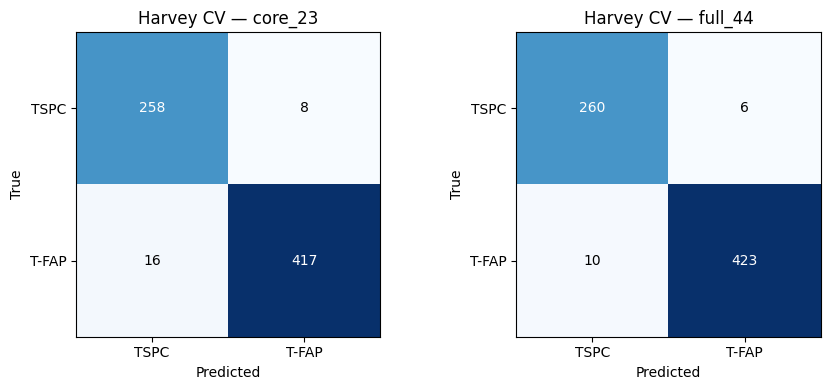

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name in zip(axes, PANELS):
    _, pred, yh = cv_preds[name]
    cm = confusion_matrix(yh, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['TSPC', 'T-FAP'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['TSPC', 'T-FAP'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Harvey CV — {name}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.tight_layout()
fig.savefig(OUT_FIG / 'harvey_cv_confusion.png', dpi=150)
plt.show()

## 4. Fit final classifiers on all of Harvey, save

The CV loop above is for honest performance estimation; the deployed model for validation and Stage 9 is refit on all 699 Harvey cells (scaler + classifier bundled together, since the scaler is stateful and must be reused unchanged on new data).

In [6]:
final_models = {}
for name, (Xh, yh, _) in harvey_data.items():
    scaler = StandardScaler().fit(Xh)
    clf = LogisticRegression(penalty='l2', class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    clf.fit(scaler.transform(Xh), yh)
    final_models[name] = {'scaler': scaler, 'clf': clf, 'genes': PANELS[name]}
    joblib.dump(final_models[name], OUT_DATA / f'classifier_{name}.joblib')
print('Saved:', [f'classifier_{n}.joblib' for n in final_models])

Saved: ['classifier_core_23.joblib', 'classifier_full_44.joblib']


C:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 5. Validation 1 — cross-dataset generalisation on Cherief 2023

Apply the Harvey-fit scaler and classifier, unchanged, to Cherief's independently-labelled TSPC/T-FAP cells. No refitting on Cherief — this is a true out-of-dataset prediction, the strongest test available given neither dataset has biological replicates.

In [7]:
def external_evaluate(model_bundle, X, y):
    proba = model_bundle['clf'].predict_proba(model_bundle['scaler'].transform(X))[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        'roc_auc': roc_auc_score(y, proba),
        'accuracy': accuracy_score(y, pred),
        'balanced_accuracy': balanced_accuracy_score(y, pred),
        'f1': f1_score(y, pred),
    }
    return metrics, proba, pred

ext_metrics, ext_preds = {}, {}
for name in PANELS:
    Xc, yc, _ = cherief_data[name]
    metrics, proba, pred = external_evaluate(final_models[name], Xc, yc)
    ext_metrics[name] = metrics
    ext_preds[name] = (proba, pred, yc)

ext_summary = pd.DataFrame(ext_metrics).T
ext_summary.to_csv(OUT_DATA / 'cherief_generalization_metrics.csv')
ext_summary

,roc_auc,accuracy,balanced_accuracy,f1
core_23,0.989022,0.934552,0.883304,0.957027
full_44,0.977229,0.926887,0.881618,0.951562


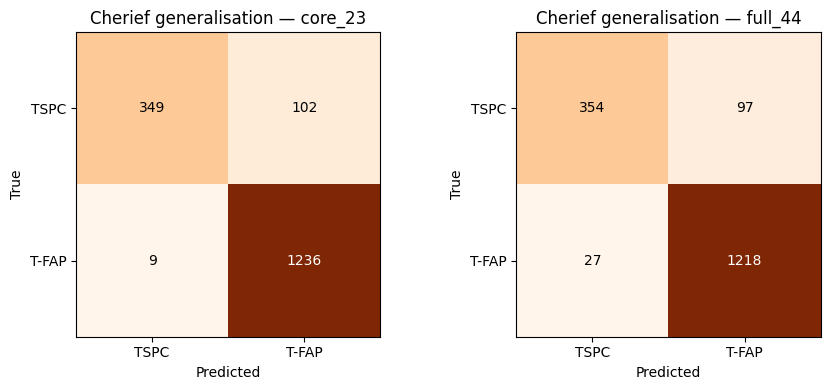

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name in zip(axes, PANELS):
    _, pred, yc = ext_preds[name]
    cm = confusion_matrix(yc, pred)
    im = ax.imshow(cm, cmap='Oranges')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['TSPC', 'T-FAP'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['TSPC', 'T-FAP'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Cherief generalisation — {name}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.tight_layout()
fig.savefig(OUT_FIG / 'cherief_generalization_confusion.png', dpi=150)
plt.show()

## 6. Validation 2 — distributional shift, innervated vs. denervated

Score every one of the 3,900 Cherief cluster-8 cells (all four sub-populations: Stromal, Tenogenic-progenitor, TSPC, T-FAP — not just the labelled TSPC/T-FAP subset), the same population Stage 4's CellRank fate probabilities were computed over. If the classifier has learned real TSPC-vs-T-FAP biology rather than dataset-specific noise, its P(T-FAP) score should shift toward T-FAP upon denervation, matching CellRank's independently-derived 17.2% → 28.9% T-FAP fate-probability shift.

In [9]:
ad_full = sc.read_h5ad(DATA_CH / 'GSE244921_cluster8_sub.h5ad')
ad_full = ad_full.raw.to_adata()

score_df = pd.DataFrame(index=ad_full.obs_names)
for name, genes in PANELS.items():
    Xm = ad_full[:, genes].X
    Xm = Xm.toarray() if hasattr(Xm, 'toarray') else np.asarray(Xm)
    Xdf = pd.DataFrame(Xm, columns=genes, index=ad_full.obs_names)
    score_df[name] = final_models[name]['clf'].predict_proba(final_models[name]['scaler'].transform(Xdf))[:, 1]

cond_label_map = {'TrkAWT': 'Innervated', 'TrkAF592A': 'Denervated'}
score_df['condition'] = ad_full.obs['condition'].map(cond_label_map).values
score_df['cell_type'] = ad_full.obs['cell_type'].values
score_df.to_csv(OUT_DATA / 'cherief_healing_index_scores.csv')

shift_summary = score_df.groupby('condition')[list(PANELS)].mean()
shift_summary.loc['shift (Denervated - Innervated)'] = shift_summary.loc['Denervated'] - shift_summary.loc['Innervated']
shift_summary

C:\Users\fangy\AppData\Local\Temp\ipykernel_12384\3669621604.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shift_summary = score_df.groupby('condition')[list(PANELS)].mean()


,core_23,full_44
condition,,
Denervated,0.880615,0.817723
Innervated,0.731997,0.684321
shift (Denervated - Innervated),0.148617,0.133402


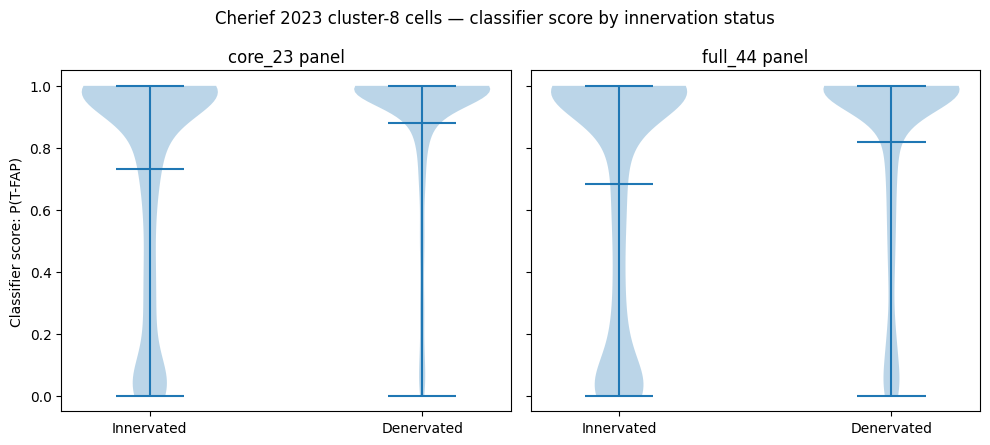

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, name in zip(axes, PANELS):
    data = [score_df.loc[score_df['condition'] == c, name].values for c in ['Innervated', 'Denervated']]
    ax.violinplot(data, showmeans=True)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['Innervated', 'Denervated'])
    ax.set_title(f'{name} panel')
axes[0].set_ylabel('Classifier score: P(T-FAP)')
fig.suptitle('Cherief 2023 cluster-8 cells — classifier score by innervation status')
fig.tight_layout()
fig.savefig(OUT_FIG / 'score_shift_by_condition.png', dpi=150)
plt.show()

## 7. Summary for Stage 9

**Harvey 2019, 10-fold CV (cell-level, not sample-replicated):** `core_23` ROC-AUC 0.993, accuracy 96.6%, F1 0.972. `full_44` ROC-AUC 0.995, accuracy 97.7%, F1 0.981 — the larger panel edges out the smaller one on its own training data, as expected.

**Cherief 2023, cross-dataset generalisation (independent `cell_type` annotation, not label-transferred):** `core_23` ROC-AUC 0.989, accuracy 93.5%, balanced accuracy 88.3%, F1 0.957. `full_44` ROC-AUC 0.977, accuracy 92.7%, balanced accuracy 88.2%, F1 0.952. **The 23-gene panel matches or slightly beats the 44-gene panel out-of-dataset despite trailing it in-dataset** — a real generalisation win for the smaller panel, not just a tie, and grounds for recommending `core_23` as the Stage 9 primary panel (Occam's razor: fewer genes, equal or better held-out performance).

**Both panels have a real, consistent weak point:** TSPC recall on Cherief is only 77–78% (102/451 and 97/451 true TSPC cells misclassified as T-FAP for `core_23`/`full_44` respectively), while T-FAP recall is 98–99%. This is why balanced accuracy (~88%) sits well below raw accuracy (~93%) — the classifier is very good at spotting T-FAP but under-calls TSPC, mirroring the training asymmetry (266 TSPC vs. 433 T-FAP in Harvey) and the earlier Stage 3A finding that TSPC has a weaker, harder-to-pin-down transcriptional signature than T-FAP in this system (0 consistent TSPC regulons vs. 15 T-FAP regulons). **This is a limitation to carry into Stage 9, not a bug to silently fix**: the continuous healing-index score will likely be more reliable at flagging fibrotic (T-FAP-like) drift than at confidently calling a cell fully regenerative (TSPC-like).

**Distributional shift, innervated → denervated, mean P(T-FAP) across all 3,900 cluster-8 cells:** `core_23` 0.732 → 0.881, `full_44` 0.684 → 0.818 — both shift in the correct direction, qualitatively consistent with CellRank's independently-derived 17.2% → 28.9% T-FAP fate-probability shift (Stage 4). Two things temper a stronger claim than "same direction": (1) units aren't comparable — this is a logistic-regression class probability from a binary TSPC/T-FAP classifier, CellRank's number is a diffusion-pseudotime fate probability from an unrelated model, so only the *sign* of the shift is a fair cross-check, not the magnitude. (2) part of the population-level shift is a composition effect already documented in Stage 1c: T-FAP's share of cluster-8 rises from 26.3% (innervated) to 38.4% (denervated) while TSPC's share falls from 15.8% to 6.7%, so more of the population is literally T-FAP-labelled under denervation, independent of any per-cell change. **There is still a genuine within-population signal on top of that**: restricting to only TSPC-labelled cells, their mean score rises from 0.217 (innervated) to 0.381 (denervated, `core_23`) — i.e. cells still called TSPC look more T-FAP-shifted transcriptionally after denervation, a graded-drift signal consistent with Stage 4's fate-probability framing rather than a clean binary switch. (T-FAP-labelled cells are already near ceiling, ~0.98, in both conditions, so that side of the comparison is saturated and uninformative for a shift check.)

**Recommendation for Stage 9:** use `classifier_core_23.joblib` (saved to `data/classifier/`) as the primary model; its `predict_proba` output is the direct input for the continuous healing-index score. Keep `classifier_full_44.joblib` on hand for a robustness/sensitivity pass. Report the TSPC-recall weak point alongside any continuous score, since it means the score is asymmetric — better calibrated for detecting fibrotic drift than for confidently confirming full regenerative identity.

**Caveats carried forward:** no biological replicates in either dataset. No batch correction between Harvey and Cherief beyond per-gene standardisation fit on Harvey alone — cross-dataset technical differences (different labs, different injury models — uninjured Harvey vs. post-injury Cherief) are not explicitly modelled, so the ~93% Cherief accuracy should be read as a real but not definitive generalisation estimate. Cherief's T-FAP cluster inherits the interpretive caveat already on record for Harvey's T-FAP (Stage 0/2): a project-defined annotation, not a state independently established in either source paper.